### Build a basic chatbot with Langgraph (GRAPH API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict) :
    # messages have the type "list". the "add_messages" function
    # int the annotated defines how this state key should be updated
    # (in this case, it appends messages to the list, rather then overwritting them)
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [4]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

model = "openai/gpt-oss-120b"

In [5]:
llm = ChatGroq(model=model)
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001986C5A8980>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001986C5A96A0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [6]:
# another way
llm = init_chat_model(f"groq:{model}")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001986C6760D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001986C676AD0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None)

In [7]:
# Node Functionality
def chatbot(state:State) :
    return {"messages": [llm.invoke(state["messages"])]}

In [8]:
graph_builder = StateGraph(State)

# add node
graph_builder.add_node("llmchatbot", chatbot)

# add edges
graph_builder.add_edge(START, "llmchatbot")
graph_builder.add_edge("llmchatbot", END)

# compile the graph
graph = graph_builder.compile()

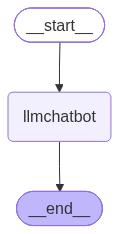

In [9]:
# visualize the graph
from IPython.display import Image, display

png_data = graph.get_graph().draw_mermaid_png()

try:
    display(Image(data = png_data))
except Exception :
    pass

In [10]:
response = graph.invoke({"messages": "hii"})
print(response)

{'messages': [HumanMessage(content='hii', additional_kwargs={}, response_metadata={}, id='d28a0cf0-c658-41dc-87c8-c62da9fb7f92'), AIMessage(content='Hi there! 👋 How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "hii". Simple greeting. We respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 36, 'prompt_tokens': 73, 'total_tokens': 109, 'completion_time': 0.074793949, 'completion_tokens_details': {'reasoning_tokens': 15}, 'prompt_time': 0.014060766, 'prompt_tokens_details': None, 'queue_time': 0.465237317, 'total_time': 0.088854715}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_c868cf1eaa', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00a3b-0ce0-7063-94da-4a0d58cd3b0b-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 73, 'output_tokens': 36, 'total_tokens': 109, 'output_token_details': {'reasoning': 15}})]}


In [11]:
print(response["messages"][-1].content)

Hi there! 👋 How can I help you today?


In [12]:
for event in graph.stream({"messages": "Hi, How are you?"}) :
    for value in event.values() :
        print(value["messages"][-1].content)

Hello! I'm doing great, thanks for asking. How can I assist you today?


### ChatBot with tools

In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results = 2)

tool.invoke("What is langgraph")

{'query': 'What is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API [...] ## Building a Simple Chatbot with LangGraph\n\nLangGraph makes it easy to build structured, stateful applications like chatbots. In this example we’ll learn how 

In [14]:
# custom function
def multiply(a:int, b:int)->int:
    """ Multiply a and b
    Args:
        a (int): first int
        b (int): second int
    
    Returns:
        int: output int
    """
    return a*b

In [15]:
tools = [tool, multiply]

In [16]:
llm_with_tools = llm.bind_tools(tools)

In [17]:
llm_with_tools

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.5.3', 'langchain': '1.3.14'}}, output_version=None, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001986C6760D0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001986C676AD0>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'), groq_api_base=None, groq_proxy=None), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description':

In [18]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", END)

# compile
graph = builder.compile()


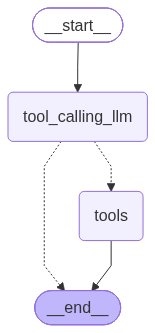

In [19]:
graph

In [20]:
msg = "what is the recent AI news"
response = graph.invoke({"messages": [("human", msg)]})

In [21]:
response["messages"][-1].content

'{"query": "latest AI news August 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jpost.com/business-and-innovation/article-905614", "title": "US to warn partners they cannot join AI coalition if they sign with Beijing - jpost.com", "content": "# US to warn partners they must pick sides in artificial intelligence race with China\\n\\n## Washington last year launched the Pax Silica initiative aimed at securing supply chains for AI models, semiconductors and critical minerals, amid a fierce technology rivalry with Beijing.\\n\\nFollow us on Google\\n\\nRepublican presidential nominee and former US President Donald Trump gestures as he attends a press conference at Trump National Golf Club, in Bedminster, New Jersey, US, August 15, 2024.\\n\\n(photo credit: REUTERS/JEENAH MOON/FILE PHOTO)\\n\\nByREUTERS\\n\\nUpdated:", "score": 0.8351749, "raw_content": null, "id": "d58fb1-00"}, {"url": "https://www.nytimes.com/spotlight/artificial-intell

In [22]:
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent AI news
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_3d48757c-fdca-4c2a-ae19-236ad7fb693e)
 Call ID: fc_3d48757c-fdca-4c2a-ae19-236ad7fb693e
  Args:
    query: latest AI news August 2024
    search_depth: advanced
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2024", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.jpost.com/business-and-innovation/article-905614", "title": "US to warn partners they cannot join AI coalition if they sign with Beijing - jpost.com", "content": "# US to warn partners they must pick sides in artificial intelligence race with China\n\n## Washington last year launched the Pax Silica initiative aimed at securing supply chains for AI models, semic

In [23]:
msg = "what is 2 multply by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is 2 multply by 3
================================== Ai Message ==================================

2 × 3 = 6.


In [24]:
msg = "what is the recent ai news and then multply 5 by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and then multply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_0e365c05-fde9-4c74-a04a-733c48413e3a)
 Call ID: fc_0e365c05-fde9-4c74-a04a-733c48413e3a
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: week
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.globalxetfs.com/articles/the-next-big-theme-august-2026", "title": "The Next Big Theme: August 2026", "content": "Alibaba unveiled Qwen3.8-Max, its largest and most capable AI model to date. The 2.4 trillion-parameter model is designed for enterprise workloads, including coding, research, multimodal reasoning, and long-h

### ReAct Agent Architecture

In [25]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile
graph = builder.compile()


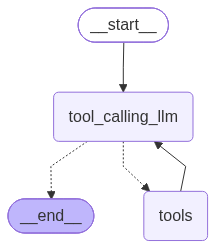

In [26]:
graph

In [27]:
msg = "what is the recent ai news and then multply 5 by 3"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is the recent ai news and then multply 5 by 3
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_1f694238-e358-49f5-9401-db091b0ce540)
 Call ID: fc_1f694238-e358-49f5-9401-db091b0ce540
  Args:
    query: latest AI news August 2026
    search_depth: advanced
    time_range: month
================================= Tool Message =================================
Name: tavily_search

{"query": "latest AI news August 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"title": "AI News Briefs BULLETIN BOARD for August 2026 | Radical Data Science", "url": "https://radicaldatascience.wordpress.com/2026/08/12/ai-news-briefs-bulletin-board-for-august-2026", "content": "[8/7/2026] The next chapter of our AI momentum – Google advances AI capabilities with new features across products like Gmail and Maps. These updates includ

### Adding Memory in Agentic Graph

In [28]:
msg = "Hello, My name is Gourab Das"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hello, My name is Gourab Das
================================== Ai Message ==================================

Hello Gourab! 👋 Nice to meet you. I’m ChatGPT, here to help with information, brainstorming, problem‑solving, writing, coding, or just a friendly chat. How can I assist you today?


In [29]:
msg = "what is my name?"
response = graph.invoke({"messages": msg})
for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

what is my name?
================================== Ai Message ==================================

I’m afraid I don’t have any information about your name. If you’d like to share it, feel free to let me know!


In [30]:
# StateGraph
from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

# node defination
def tool_calling_llm(State: State) :
    return {"messages": [llm_with_tools.invoke(State["messages"])]}


# Graph
builder = StateGraph(State)
builder.add_node("tool_calling_llm", tool_calling_llm)
builder.add_node("tools", ToolNode(tools))

# add edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # if the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # if the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools", "tool_calling_llm")

# compile
graph = builder.compile(checkpointer=memory) 

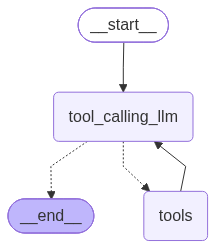

In [31]:
graph

In [32]:
config = {"configurable": {"thread_id": "user1"}}
msg = "Hii, I am Gourab..."

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Hello Gourab! 👋 Great to meet you. How can I assist you today?


In [33]:
config = {"configurable": {"thread_id": "user1"}}
msg = "What is my name?"

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Hello Gourab! 👋 Great to meet you. How can I assist you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Gourab.


In [34]:
config = {"configurable": {"thread_id": "user1"}}
msg = "what you know about me?"

response = graph.invoke({"messages":msg}, config=config)

for m in response["messages"] :
    m.pretty_print()

================================ Human Message =================================

Hii, I am Gourab...
================================== Ai Message ==================================

Hello Gourab! 👋 Great to meet you. How can I assist you today?
================================ Human Message =================================

What is my name?
================================== Ai Message ==================================

Your name is Gourab.
================================ Human Message =================================

what you know about me?
================================== Ai Message ==================================

I only know what you’ve shared with me so far—your name is **Gourab**. If there’s anything specific you’d like me to keep in mind or any details you’d like to share, just let me know!


### Streaming

create a simple graph

In [35]:
# inecelize the memory
from langgraph.checkpoint.memory import MemorySaver
memory = MemorySaver()

In [36]:
# node defination
def superbot(state:State) :
    return {"messages":[llm.invoke(state['messages'])]}

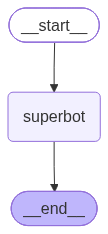

In [37]:
# state graph
graph = StateGraph(State)

# node
graph.add_node("superbot", superbot)

# edges
graph.add_edge(START, "superbot")
graph.add_edge("superbot", END)

# compile
graph_builder = graph.compile(checkpointer=memory)

graph_builder

In [38]:
# Invocation
config = {"configurable": {"thread_id": "gd_1"}}
graph_builder.invoke({"messages": "Hi, My name is Gourab and I like cricket"}, config)

{'messages': [HumanMessage(content='Hi, My name is Gourab and I like cricket', additional_kwargs={}, response_metadata={}, id='e80e6739-be71-46a6-8095-39035238370b'),
  AIMessage(content="Hey Gourab! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player? Are you more into the fast‑bowling action, the strategic spin game, or maybe the thrill of a big chase? I'd love to hear what you enjoy most about cricket!", additional_kwargs={'reasoning_content': 'The user says: "Hi, My name is Gourab and I like cricket". Probably wants a response. We can greet them, ask about cricket preferences. There\'s no policy violation. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 82, 'total_tokens': 196, 'completion_time': 0.237834611, 'completion_tokens_details': {'reasoning_tokens': 42}, 'prompt_time': 0.003131399, 'prompt_tokens_details': None, 'queue_time': 0.31410355, 'total_time': 0.24096601}, 'model_name':

### Streaming

Methods: .stream() and astream()

- These methods are sync and async methods for streaming back results.

Additional parameters in streaming modes for graph state
- values: This streams the full state of the graph after each node is called.
- updates: This streams updates to the state of the graph after each node is called.

In [39]:
# create a thread
config = {"configurable": {"thread_id":"user_4"}}

response = graph_builder.stream(
    {
        "messages": "Hi, my nme is Gourab and I like cricket"
    },
    config,
    stream_mode="updates"
)
for chunk in response :
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hi Gourab! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player you follow?', additional_kwargs={'reasoning_content': 'The user says "Hi, my nme is Gourab and I like cricket". Likely they are just greeting, maybe want a response. We should respond politely, maybe ask about favorite team, etc. No disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 83, 'total_tokens': 173, 'completion_time': 0.187505183, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.014735917, 'prompt_tokens_details': None, 'queue_time': 0.31583234, 'total_time': 0.2022411}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a00a43-e5b9-71f2-8c3c-7b1791fa4088-0', tool_calls=[], invalid_tool_calls=[], usage

In [40]:
response = graph_builder.stream(
    {
        "messages": "Hi, my nme is Gourab and I like cricket"
    },
    config,
    stream_mode="values"
)
for chunk in response :
    print(chunk)

{'messages': [HumanMessage(content='Hi, my nme is Gourab and I like cricket', additional_kwargs={}, response_metadata={}, id='b7ed0364-c764-430b-b09a-081175c7bbf1'), AIMessage(content='Hi Gourab! 👋 Great to meet you. Cricket is such an exciting sport—do you have a favorite team or player you follow?', additional_kwargs={'reasoning_content': 'The user says "Hi, my nme is Gourab and I like cricket". Likely they are just greeting, maybe want a response. We should respond politely, maybe ask about favorite team, etc. No disallowed content. Just respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 83, 'total_tokens': 173, 'completion_time': 0.187505183, 'completion_tokens_details': {'reasoning_tokens': 52}, 'prompt_time': 0.014735917, 'prompt_tokens_details': None, 'queue_time': 0.31583234, 'total_time': 0.2022411}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_60e4b492db', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'l

In [41]:
# create a thread
config = {"configurable": {"thread_id":"user_3"}}

response = graph_builder.stream(
    {
        "messages": "Hi, my nme is Gourab and I like cricket"
    },
    config,
    stream_mode="updates"
)
for chunk in response :
    print(chunk)

{'superbot': {'messages': [AIMessage(content='Hello Gourab! Nice to meet you. 😊  \nIt sounds like you’re a cricket fan—what’s your favorite team or player? Do you follow any particular league or tournament right now? Feel free to share any cricket stories or ask anything you’d like!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi, my nme is Gourab and I like cricket". We should greet them, correct typo maybe, ask about cricket preferences, maybe ask what they want to talk about. Follow OpenAI policy. Simple.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 83, 'total_tokens': 201, 'completion_time': 0.244786125, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.003308183, 'prompt_tokens_details': None, 'queue_time': 0.36835725, 'total_time': 0.248094308}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_93703442d9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logpr

In [42]:
response = graph_builder.stream(
    {
        "messages": "I also Like football"
    },
    config,
    stream_mode="values"
)
for chunk in response :
    print(chunk)

{'messages': [HumanMessage(content='Hi, my nme is Gourab and I like cricket', additional_kwargs={}, response_metadata={}, id='5747fed7-9436-435c-9eb5-e78cb99d5224'), AIMessage(content='Hello Gourab! Nice to meet you. 😊  \nIt sounds like you’re a cricket fan—what’s your favorite team or player? Do you follow any particular league or tournament right now? Feel free to share any cricket stories or ask anything you’d like!', additional_kwargs={'reasoning_content': 'We need to respond as ChatGPT. The user says "Hi, my nme is Gourab and I like cricket". We should greet them, correct typo maybe, ask about cricket preferences, maybe ask what they want to talk about. Follow OpenAI policy. Simple.'}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 83, 'total_tokens': 201, 'completion_time': 0.244786125, 'completion_tokens_details': {'reasoning_tokens': 56}, 'prompt_time': 0.003308183, 'prompt_tokens_details': None, 'queue_time': 0.36835725, 'total_time': 0.248094308

astream

In [44]:
# create a thread
config = {"configurable": {"thread_id":"user_5"}}

response = graph_builder.astream_events(
    {
        "messages": "Hi, my nme is Gourab and I like cricket"
    },
    config,
    version = "v2"
)
async for event in response :
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'Hi, my nme is Gourab and I like cricket'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a00a4d-eba6-72f1-875d-0021188a92fd', 'metadata': {'thread_id': 'user_5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi, my nme is Gourab and I like cricket', additional_kwargs={}, response_metadata={}, id='229c4b41-cb12-4320-942b-5385bbe376b2')]}}, 'name': 'superbot', 'tags': ['graph:step:1'], 'run_id': '01a00a4d-ebab-78a0-9783-05281a6cbac1', 'metadata': {'thread_id': 'user_5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superbot', 'langgraph_triggers': ('branch:to:superbot',), 'langgraph_path': ('__pregel_pull', 'superbot'), 'langgraph_checkpoint_ns': 'superbot:dc8fbe0f-e7b5-3d57-b8a8-90151c725017'}, 'parent_ids': ['01a00a4d-eba6-72f1-875d-0021188a92fd']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[Hum